## Análisis de Datos Meteorológicos con una API Pública
Obtener datos del clima de una ciudad usando la API de Open-Meteo (https://open-meteo.com/) y mostrar el pronóstico para Bilbao.

* Haz una petición a la API para que devuelva el pronóstico de las temperaturas para una semana en Bilbao. Tip: el parámetro correspondiente en el query es `temperature_2m` además de la latitud y la longitud.
* Procesa la respuesta en formato JSON para obtener dos listas: una con la lista de temperaturas y otra con las fechas-horas correspondientes.
* Crea un DataFrame con esas dos columnas: `Hora` y `Temperatura`
* Elige la gráfica adecuada y visualiza el pronóstico de temperaturas.

Para crear la variable `Hora` del DataFrame puedes introducir directamente la lista que se obtiene del campo `data["hourly"]["time"]` o procesar esa lista mediante el siguiente código:

`hours = pd.date_range(start=lista_de_horas, periods=len(temps), freq="H")`

### Paso 1 — Importamos las librerías que necesitamos

In [1]:
import requests          # Para hacer la petición a la API (ir a la URL y traernos los datos)
import pandas as pd      # Para organizar los datos en un DataFrame
import matplotlib.pyplot as plt  # Para hacer la gráfica

### Paso 2 — Definimos las coordenadas de Bilbao y construimos la URL

In [2]:
# Coordenadas de Bilbao (las que nos dan en el enunciado)
latitude = 43.2540
longitude = -2.9230

# Construimos la URL con los parámetros que necesita la API:
# - latitude y longitude: le decimos DÓNDE queremos el pronóstico
# - hourly=temperature_2m: le decimos QUÉ dato queremos (temperatura hora a hora)
url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&hourly=temperature_2m"

# Comprobamos cómo queda la URL
print(url)

https://api.open-meteo.com/v1/forecast?latitude=43.254&longitude=-2.923&hourly=temperature_2m


### Paso 3 — Hacemos la petición a la API y extraemos los datos

In [3]:
# Hacemos la petición: Python va a esa URL y nos trae la respuesta
response = requests.get(url)

# Convertimos la respuesta JSON en un diccionario de Python
data = response.json()

# Echamos un vistazo a las claves del diccionario para entender su estructura
print("Claves principales:", data.keys())
print()
print("Claves dentro de 'hourly':", data["hourly"].keys())

Claves principales: dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

Claves dentro de 'hourly': dict_keys(['time', 'temperature_2m'])


In [4]:
# Extraemos las dos listas que necesitamos:
# - horas: la lista de fechas-horas (son strings tipo "2026-03-23T00:00")
# - temps: la lista de temperaturas en ºC
horas = data["hourly"]["time"]
temps = data["hourly"]["temperature_2m"]

# Comprobamos cuántos datos tenemos (debería ser 168 = 7 días x 24 horas)
print(f"Tenemos {len(horas)} registros horarios")
print()
print("Primeras 5 horas:", horas[:5])
print("Primeras 5 temperaturas:", temps[:5])

Tenemos 168 registros horarios

Primeras 5 horas: ['2026-03-23T00:00', '2026-03-23T01:00', '2026-03-23T02:00', '2026-03-23T03:00', '2026-03-23T04:00']
Primeras 5 temperaturas: [12.3, 12.1, 11.8, 11.5, 11.1]


### Paso 4 — Creamos el DataFrame

In [5]:
# Creamos el DataFrame con las dos columnas que nos pide el enunciado
# Usamos pd.to_datetime() para que Pandas entienda las horas como fechas reales,
# no como simples cadenas de texto
df = pd.DataFrame({
    "Hora": pd.to_datetime(horas),
    "Temperatura": temps
})

# Comprobamos el resultado
df.head(10)

,Hora,Temperatura
0,2026-03-23 00:00:00,12.3
1,2026-03-23 01:00:00,12.1
2,2026-03-23 02:00:00,11.8
3,2026-03-23 03:00:00,11.5
4,2026-03-23 04:00:00,11.1
5,2026-03-23 05:00:00,10.7
6,2026-03-23 06:00:00,10.8
7,2026-03-23 07:00:00,11.0
8,2026-03-23 08:00:00,12.0
9,2026-03-23 09:00:00,13.2


In [6]:
# Verificamos los tipos de dato: Hora debe ser datetime64, Temperatura debe ser float
df.dtypes

Hora           datetime64[us]
Temperatura           float64
dtype: object

### Paso 5 — Visualizamos el pronóstico con un gráfico de líneas

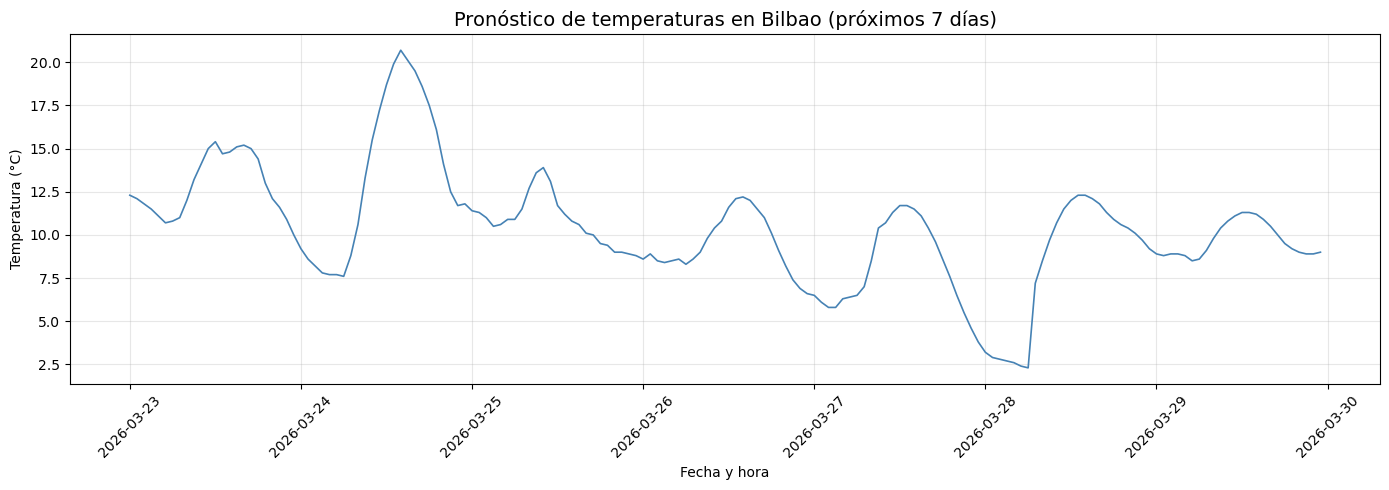

In [7]:
# Elegimos un gráfico de líneas porque queremos ver cómo evoluciona
# la temperatura a lo largo del tiempo (es una serie temporal)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["Hora"], df["Temperatura"], color="steelblue", linewidth=1.2)

ax.set_title("Pronóstico de temperaturas en Bilbao (próximos 7 días)", fontsize=14)
ax.set_xlabel("Fecha y hora")
ax.set_ylabel("Temperatura (°C)")
ax.grid(True, alpha=0.3)

# Rotamos las etiquetas del eje X para que se lean bien
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()